# RAG System Prototype for Course Material Question Answering

This notebook demonstrates a small scale implementation of a Retrieval-Augmented Generation (RAG) system. The system processes and indexes sample course material, retrieves relevant chunks based on a user query, builds a prompt, and finally generating an answer using a language model (LLM).

In [1]:
# Uncomment and run the following cell to install required packages if needed
# !pip install sentence-transformers faiss-cpu openai
# !pip install transformers accelerate torch
# !pip install sacrebleu rouge-score bert-score
# !pip install nltk

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
from sacrebleu import corpus_bleu
from rouge_score import rouge_scorer
from bert_score import score as bert_score

# LLM Agent Class

In [3]:
from openai import OpenAI

openAiKeyFile = open('openaikey.txt', 'r', encoding='utf-8')
OpenAI_API_KEY = openAiKeyFile.readline().strip()
openAiKeyFile.close()
openai_models = [
    "gpt-3.5-turbo",
    "gpt-3.5-turbo-16k",
    "gpt-4-turbo",
    "gpt-4",
    "gpt-4o-mini",
    "gpt-4o"
]
LLM_Model = openai_models[0]

# Define the LlmAgent class
class LlmAgent:
    def __init__(self, name, key, model, temperature):
        self.name = name
        self.temperature = temperature
        self.model = model
        self.client = OpenAI(api_key=key)
        self.messages = []

    def initializeAgent(self, system_prompt):
        self.messages.append({"role": "system", "content": system_prompt})

    def sendMessage(self, userinput):
        self.messages.append({"role": "user", "content": userinput})

    def getResponse(self):
        response = self.client.chat.completions.create(model=self.model, messages=self.messages)
        response_message = response.choices[0].message.content
        self.messages.append({"role": "assistant", "content": response_message})
        return response_message

# Define a function to create an agent
def create_agent(role_name, description, key, model=LLM_Model, temperature=1.0):
    agent = LlmAgent(name=role_name, key=key, model=model, temperature=temperature)
    system_prompt = f"""
    You are the {role_name}. {description}
    """
    agent.initializeAgent(system_prompt)
    return agent
    

# RAG Functions

In [4]:
import numpy as np
import nltk
from sentence_transformers import SentenceTransformer, util
import faiss

# download nltk data
nltk.download('all')

# take in text with punctuation and split into chunks
def chunk_text(text, chunk_size, overlap):
    sentences = nltk.sent_tokenize(text)
    chunks = []
    start = 0
    while start < len(sentences):
        chunk = sentences[start: start + chunk_size]
        chunks.append(' '.join(chunk))
        start += (chunk_size - overlap)
    return chunks

# def chunk_text(text, chunk_size, overlap):
#     """
#     Splits the text into chunks of a given size with an overlap to maintain context.
#     """
#     words = text.split()
#     chunks = []
#     start = 0
#     while start < len(words):
#         chunk = words[start: start + chunk_size]
#         chunks.append(' '.join(chunk))
#         start += (chunk_size - overlap)
#     return chunks

# Load a pre-trained Sentence Transformer model for embedding
model = SentenceTransformer('all-MiniLM-L6-v2')

def embed_texts(texts):
    """
    Computes vector embeddings for a list of texts using the pre-trained model.
    """
    embeddings = model.encode(texts)
    return embeddings

def build_faiss_index(embeddings):
    """
    Builds a FAISS index from the given embeddings for efficient similarity search.
    """
    dim = embeddings.shape[1]
    #index = faiss.IndexFlatL2(dim)
    index = faiss.IndexFlatIP(dim) # inner product
    faiss.normalize_L2(embeddings) # new =)
    index.add(embeddings.astype('float32'))
    #index.add(embeddings)
    return index

def keyword_score(query, chunk):
    query = query.split() # ["What", "is", "y"]
    chunk = chunk.split() # ["What", "is", "y"]

    query_words = {word.strip('.,!?').lower() for word in query}
    chunk_words = {word.strip('.,!?').lower() for word in chunk}
    return len(query_words.intersection(chunk_words))

def retrieve(query, chunks, index, k):
    """
    Retrieves the top-k most relevant text chunks for a given query.
    First, retieve 2*k chunks based on the embeddings.
    Second, sort them based on the actual keywords relevance.
    Third, picks the top-k chunks.
    """
    query_embedding = model.encode([query])
    faiss.normalize_L2(query_embedding) # new =)
    D, I = index.search(np.array(query_embedding).astype('float32'), 2 * k)
    retrieved_chunks = [chunks[i] for i in I[0]]

    retrieved_chunks.sort(key = lambda chunk: keyword_score(query, chunk), reverse = True)

    return retrieved_chunks[:k]    

    
# def build_prompt(query, retrieved_chunks):
#     """
#     Combines the user query with retrieved context chunks to build a prompt for the LLM.
#     """
#     context_chunks = "".join(retrieved_chunks)

#     prompt = f"""You are a helpful teaching assistant answering questions. 
#                 Please read the **Context** and **Question** below and try to extract a cohesive answer from the context.
#                 Do not use your own knowledge and stick to the context being given to you.
#                 Please give a brief answer that matches the context wording as much as possible.\n
#                 **Context**: {context_chunks}\n
#                 **Question**: {query}"""
#     return prompt


# def build_prompt(question, retrieved_chunks):
#     joined_chunks = "\n\n".join(retrieved_chunks)
#     prompt = f"""You are a highly knowledgeable and precise teaching assistant helping a student understand course materials.
            
#             Below are some extracted chunks from the course readings that may be relevant:
            
#             <CHUNKS>
#             {joined_chunks}
#             </CHUNKS>
            
#             Using ONLY the information in the provided chunks (do not hallucinate or invent new facts), please answer the following question carefully and completely:
            
#             <QUESTION>
#             {question}
#             </QUESTION>
            
#             If the answer cannot be found within the chunks, reply:
            
#             "I could not find the answer in the provided material."
            
#             Your answer should be clear, complete, and use the same technical level as the material.
#             """
#     return prompt


# def build_prompt(question, retrieved_chunks):
#     context = "\n\n".join(retrieved_chunks)

#     prompt = f"""Use ONLY the following Context to answer the Question. 
# Answer briefly, matching the wording as much as possible. 
# If unsure, answer: "I could not find the answer in the provided material."

# Context:
# {context}

# Question:
# {question}

# Answer:"""
#     return prompt

def build_prompt(question, retrieved_chunks):
    """
    Build a prompt that forces the model to quote directly from the retrieved context when answering.
    """
    context = "\n\n".join(retrieved_chunks)

    prompt = f"""You are an AI assistant.

Use ONLY direct quotes from the **Context** below to answer the **Question**.
- Do NOT paraphrase.
- Copy full sentences or phrases exactly as written in the Context.
- If the answer is not found, say: "I could not find the answer in the provided material."

---
Context:
{context}
---
Question:
{question}
---
Answer (quoted sentences only):"""
    return prompt


[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /Users/754346/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     /Users/754346/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /Users/754346/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /Users/754346/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /Users/754346/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_ru is already
[nltk_data]    |       up-to-date!
[nlt

# Processing and Indexing Course Material

In [5]:
import os
import numpy as np
from tqdm import tqdm

# 2.0: Helper to load all .txt files from given folders
def load_all_texts(dirs, extensions=(".txt",)):
    docs = {}
    for d in dirs:
        for fname in os.listdir(d):
            if fname.lower().endswith(extensions):
                path = os.path.join(d, fname)
                with open(path, "r", encoding="utf-8") as f:
                    docs[fname] = f.read()
    return docs

# 2.1: Load documents
directories = ["processed_transcripts", "lecture_notes"]
documents = load_all_texts(directories)

# 2.2: Chunk each document and collect all chunks

all_chunks = []
for fname, text in documents.items():
    print(f"\n--- Processing '{fname}' ---")
    
    # Chunk it
    chunks = chunk_text(text, chunk_size=10, overlap=3)
    
    # show a progress bar instead of printing "-" lines
    for _ in tqdm(chunks, desc=f"Chunking {fname}", unit="chunk"):
        pass
    
    all_chunks.extend(chunks)

print(f"\nTotal chunks created: {len(all_chunks)}")

# 2.3: Embed all chunks
embeddings = embed_texts(all_chunks)
embeddings_np = np.array(embeddings).astype("float32")

# 2.4: Build the FAISS index
index = build_faiss_index(embeddings_np)

print("✅ All documents processed, embedded, and indexed.")



--- Processing 'lecture-7.txt' ---


Chunking lecture-7.txt: 100%|██████████████████████████| 54/54 [00:00<00:00, 820624.70chunk/s]



--- Processing 'lecture-6.txt' ---


Chunking lecture-6.txt: 100%|█████████████████████████| 63/63 [00:00<00:00, 1308124.51chunk/s]



--- Processing 'lecture-4.txt' ---


...

Chunking Classification_Lecture_Rewritten.txt: 100%|█████| 2/2 [00:00<00:00, 104857.60chunk/s]



--- Processing 'Linear_Regression_Rewritten.txt' ---


Chunking Linear_Regression_Rewritten.txt: 100%|███████████| 2/2 [00:00<00:00, 76260.07chunk/s]


Total chunks created: 1344


✅ All documents processed, embedded, and indexed.


# Retrival and Prompting

In [6]:
# Step 3.1: Define a sample query
#query = "What programming paradigms does Python support?"
query = "Why does the SVD of a matrix reveal its rank?"

# Step 3.2: Retrieve the top-k relevant chunks from the course material
retrieved_chunks = retrieve(query, all_chunks, index, k=5)
print("\nRetrieved Chunks:\n")
for chunk in retrieved_chunks:
    print(chunk)
    print("-"*50)

# Step 3.3: Build a prompt combining the query and retrieved context
prompt = build_prompt(query, retrieved_chunks)
print("\nPrompt for LLM:\n")
print(prompt)
# display(Latex(prompt))


Retrieved Chunks:

again, a very beautiful characterization of the singular value. decomposition is the following: right, if Matrix a? I haven't spoken about rank far, but if Matrix a has rank R, okay, and R has to be less than equal to minimum of MN, and if m is greater than equal to n, it means that R is less than equal to n. R is the rank of the Matrix and that's exactly equal to the number of nonzero singular values. that's really the almost numerically the best way to determine the rank of a matrix is to do an SVD. okay, let me write it out. this means that Sigma 1 is greater than equal to Sigma 2, is greater than equal to Sigma r, and this is greater than zero, and what that means is that Sigma r + 1 = Sigma r + 2 to Sigma n, equal Z. okay, and then if I think about a, my Matrix a, then I have: a is r, n to r m. this is its Ma V1, as we saw to U1, Sigma 1, V2 to U2, Sigma 2, VR to ur, Sigma r and v? r + 1. it maps to zero because the rank is r, and similarly, V? r+ r, v, n is ma

In [7]:
# Step 3.4: Generate an answer using OpenAI LLM
the_llm_agent = create_agent(role_name="RAG Agent", description="", key=OpenAI_API_KEY, model=LLM_Model, temperature=0.0)
the_llm_agent.sendMessage(prompt)
answer = the_llm_agent.getResponse()
print("\nBig LLM Answer:\n")
print(answer)
#display(Latex(answer))


Big LLM Answer:

"R is the rank of the Matrix and that's exactly equal to the number of nonzero singular values."


# Optimized pipeline

In [24]:
import pandas as pd
import bert_score
import re
import openai
from openai import OpenAI
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.tokenize import word_tokenize
from rouge_score import rouge_scorer
from tqdm import tqdm
from transformers import logging as hf_logging
hf_logging.set_verbosity_error()

# ─────────────────────────────────────────────────────────────────────
# 1. Configuration / Helpers
# ─────────────────────────────────────────────────────────────────────

# Set your OpenAI key here (or via env var)
openai.api_key = OpenAI_API_KEY

# List of models you want to compare
openai_models = [
    "gpt-3.5-turbo",
    "gpt-3.5-turbo-16k",
    "gpt-4-turbo",
    "gpt-4",
    "gpt-4o-mini",
    "gpt-4o"
]

# Create a single client instance:
client = OpenAI(api_key=OpenAI_API_KEY)

# The range of k values
k_values = list(range(2, 11))

# Pre-load scorers
_smoothing = SmoothingFunction().method1
_rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

# ─────────────────────────────────────────────────────────────────────
# 2. Classic metrics batch evaluator
# ─────────────────────────────────────────────────────────────────────

# def evaluate_classic_batch(predictions, references):
#     """
#     Compute BLEU, ROUGE-L, BERTScore-F1 for lists of predictions & references.
#     Returns a DataFrame with one row per prediction.
#     """
#     # 1) BERTScore in one shot
#     P, R, F1 = bert_score.score(predictions, references, lang="en", rescale_with_baseline=True)
#     bert_f1 = F1.tolist()
    
#     records = []
#     for pred, ref, bs in zip(predictions, references, bert_f1):
#         # BLEU
#         pred_toks = word_tokenize(pred)
#         ref_toks  = word_tokenize(ref)
#         bleu = sentence_bleu([ref_toks], pred_toks, smoothing_function=_smoothing)
#         bleu = max(0.0, min(1.0, bleu))
        
#         # ROUGE-L
#         rougeL = _rouge.score(ref, pred)["rougeL"].fmeasure
        
#         records.append({
#             "prediction": pred,
#             "reference":  ref,
#             "bleu":        bleu,
#             "avg_rougeL":  rougeL,
#             "avg_bertF1":  bs,
#         })
    
#     return pd.DataFrame.from_records(records)

def evaluate_classic_batch(predictions, references):
    """
    Compute BLEU, ROUGE-L, BERTScore-F1, SBERT Cosine Similarity for lists of predictions & references.
    Returns a DataFrame with one row per prediction.
    """
    # BERTScore
    P, R, F1 = bert_score.score(predictions, references, lang="en", rescale_with_baseline=True)
    bert_f1 = F1.tolist()

    # SBERT cosine similarity (batch)
    emb_preds = model.encode(predictions, convert_to_tensor=True)
    emb_refs  = model.encode(references, convert_to_tensor=True)
    sbert_cosine = util.cos_sim(emb_preds, emb_refs).diagonal().tolist()  # 1-to-1 match

    records = []
    for pred, ref, bs, sbert_sim in zip(predictions, references, bert_f1, sbert_cosine):
        # BLEU
        pred_toks = word_tokenize(pred)
        ref_toks  = word_tokenize(ref)
        bleu = sentence_bleu([ref_toks], pred_toks, smoothing_function=_smoothing)
        bleu = max(0.0, min(1.0, bleu))

        # ROUGE-L
        rougeL = _rouge.score(ref, pred)["rougeL"].fmeasure

        records.append({
            "prediction": pred,
            "reference":  ref,
            "bleu":        bleu,
            "avg_rougeL":  rougeL,
            "avg_bertF1":  bs,
            "sbert_cosine_sim": sbert_sim
        })

    return pd.DataFrame.from_records(records)

# ─────────────────────────────────────────────────────────────────────
# 3. Batch LLM‐based evaluator
# ─────────────────────────────────────────────────────────────────────

def batch_evaluate_with_llm(references, predictions,
                            model="gpt-4o", temperature=0.0):
    """
    Sends ALL (ref,pred) pairs in one user prompt, asks for one integer 0–10 per line,
    then parses that single assistant response into a list of floats in [0,1].
    """
    n = len(references)
    # Build one user prompt
    prompt = [
        {"role": "system",
         "content": (
             "You are an expert evaluator.  "
             f"I will give you {n} reference/prediction pairs.  "
             "For each pair, return exactly one integer score (0–10), one per line, nothing else."
         )},
        {"role": "user",
         "content": "\n\n".join(
             f"Pair {i+1}:\n"
             f"Reference: {references[i]}\n"
             f"Prediction: {predictions[i]}\n"
             for i in range(n)
         )}
    ]

    # Single API call
    resp = client.chat.completions.create(
        model=model,
        messages=prompt,
        temperature=temperature,
    )

    # This is one long string, e.g. "7\n5\n10\n0\n…"
    text = resp.choices[0].message.content.strip()

    # Split into lines and parse ints
    lines = text.splitlines()
    scores = []
    for line in lines:
        line = line.strip()
        if not line:
            continue
        # Extract first integer found
        m = re.search(r"\b([0-9]|10)\b", line)
        s = int(m.group(1)) if m else 0
        # clamp and scale to [0,1]
        s = max(0, min(10, s)) / 10.0
        scores.append(s)

    # If the model returned fewer lines than expected, pad with zeros
    if len(scores) < n:
        scores += [0.0] * (n - len(scores))
    # Or if it returned too many, truncate
    return scores[:n]

# ─────────────────────────────────────────────────────────────────────
# 4. Main RAG‐Evaluation Loop (writes to CSV once)
# ─────────────────────────────────────────────────────────────────────

def run_rag_evaluation(
    df_questions,
    models,
    k_list,
    retrieve,      # your function
    build_prompt,  # your function
    create_agent,  # your function
    all_chunks,
    index
):
    all_dfs = []
    
    for k in k_list:
        for model_name in models:
            qs = df_questions["question"].tolist()
            refs = df_questions["answer"].tolist()
            
            # 4a) Collect RAG predictions in batch
            preds = []
            for q in tqdm(qs, desc=f"k={k} • {model_name}"):
                chunks = retrieve(q, all_chunks, index, k=k)
                prm    = build_prompt(q, chunks)
                agent  = create_agent(
                    role_name="RAG Agent",
                    description="You are a helpful TA.",
                    key=openai.api_key,
                    model=model_name,
                    temperature=0.0
                )
                agent.sendMessage(prm)
                preds.append(agent.getResponse())
            
            # 4b) Classic metrics
            df_cls = evaluate_classic_batch(preds, refs)
            
            # 4c) LLM Eval (batch)
            df_cls["LLM_eval"] = batch_evaluate_with_llm(refs, preds, model=model_name)
            
            # 4d) annotate k/model
            df_cls["model"] = model_name
            df_cls["k"]     = k
            
            all_dfs.append(df_cls)
    
    df_results = pd.concat(all_dfs, ignore_index=True)
    df_results.to_csv("rag_full_eval.csv", index=False)
    return df_results

# ─────────────────────────────────────────────────────────────────────
# 5. Run & Save
# ─────────────────────────────────────────────────────────────────────

df = pd.read_csv("sample_questions/ML_Questions.csv")
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(r"\s+", "_", regex=True)
      .str.replace(r"[^\w_]", "", regex=True)
)

df_results = run_rag_evaluation(
    df_questions=df,
    models=openai_models,
    k_list=k_values,
    retrieve=retrieve,
    build_prompt=build_prompt,
    create_agent=create_agent,
    all_chunks=all_chunks,
    index=index
)


k=10 • gpt-4o: 100%|██████████████████████████████████████████| 50/50 [00:36<00:00,  1.36it/s]


In [25]:
# ─────────────────────────────────────────────────────────────────────
# 6. Produce One Multi-Row LaTeX Table
# ─────────────────────────────────────────────────────────────────────

# Read the full results from file
df_results=pd.read_csv("rag_full_eval.csv")

# average over questions for each (k, model)
df_avg = (
    df_results
      .groupby(["k","model"], as_index=False)
      [["bleu","avg_rougeL","avg_bertF1","LLM_eval","sbert_cosine_sim"]]
      .mean()
)

latex = df_avg.to_latex(
    index=False,
    float_format="%.2f",
    caption="RAG evaluation across models and k",
    label="tab:rag_comparison"
)
print(latex)


\begin{table}
\caption{RAG evaluation across models and k}
\label{tab:rag_comparison}
\begin{tabular}{rlrrrrr}
\toprule
k & model & bleu & avg_rougeL & avg_bertF1 & LLM_eval & sbert_cosine_sim \\
\midrule
2 & gpt-3.5-turbo & 0.04 & 0.17 & 0.03 & 0.20 & 0.44 \\
2 & gpt-3.5-turbo-16k & 0.03 & 0.19 & 0.05 & 0.61 & 0.50 \\
2 & gpt-4 & 0.03 & 0.19 & 0.06 & 0.72 & 0.48 \\
2 & gpt-4-turbo & 0.04 & 0.19 & 0.06 & 0.46 & 0.38 \\
2 & gpt-4o & 0.03 & 0.11 & -0.01 & 0.04 & 0.07 \\
2 & gpt-4o-mini & 0.03 & 0.17 & 0.03 & 0.26 & 0.42 \\
3 & gpt-3.5-turbo & 0.03 & 0.19 & 0.06 & 0.17 & 0.47 \\
3 & gpt-3.5-turbo-16k & 0.03 & 0.16 & 0.02 & 0.48 & 0.48 \\
3 & gpt-4 & 0.04 & 0.21 & 0.09 & 0.72 & 0.50 \\
3 & gpt-4-turbo & 0.04 & 0.21 & 0.09 & 0.53 & 0.37 \\
3 & gpt-4o & 0.03 & 0.13 & 0.02 & 0.10 & 0.13 \\
3 & gpt-4o-mini & 0.04 & 0.19 & 0.05 & 0.67 & 0.44 \\
4 & gpt-3.5-turbo & 0.04 & 0.20 & 0.09 & 0.29 & 0.53 \\
4 & gpt-3.5-turbo-16k & 0.07 & 0.23 & 0.10 & 0.85 & 0.54 \\
4 & gpt-4 & 0.06 & 0.21 & 0.09 & 0.8

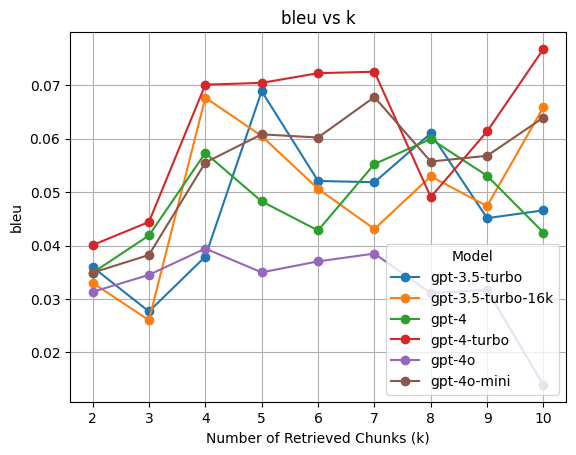

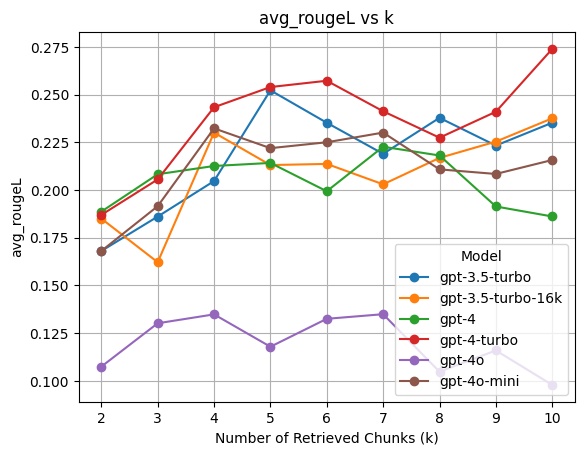

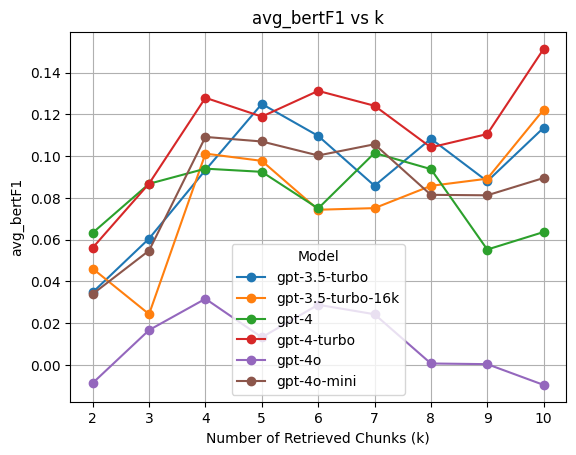

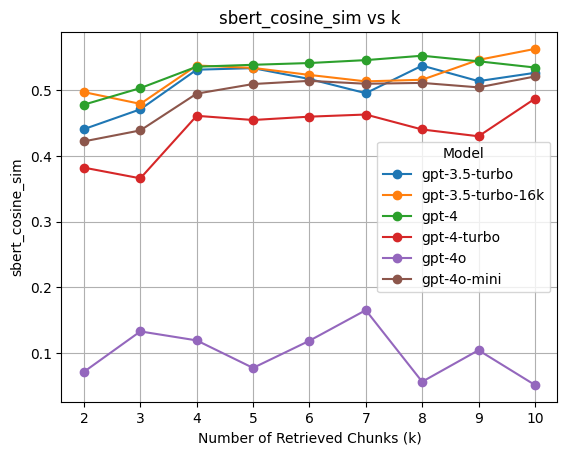

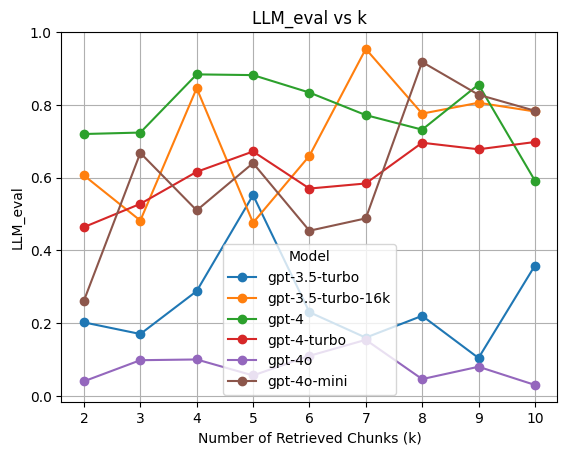

In [26]:
# ─────────────────────────────────────────────────────────────────────
# 7. Produce One Plot Per Metric
# ─────────────────────────────────────────────────────────────────────

# For each metric, plot how it evolves with k
import matplotlib.pyplot as plt

# Read the full results from file
df_results=pd.read_csv("rag_full_eval.csv")

# average over questions for each (k, model)
df_avg = (
    df_results
      .groupby(["k","model"], as_index=False)
      [["bleu","avg_rougeL","avg_bertF1","LLM_eval","sbert_cosine_sim"]]
      .mean()
)
metrics = ["bleu", "avg_rougeL", "avg_bertF1", "sbert_cosine_sim", "LLM_eval"]

for metric in metrics:
    pivot = df_avg.pivot(index='k', columns='model', values=metric)
    pivot.plot(marker='o')
    plt.title(f"{metric} vs k")
    plt.xlabel("Number of Retrieved Chunks (k)")
    plt.ylabel(metric)
    plt.legend(title="Model")
    plt.grid()
    plt.show()


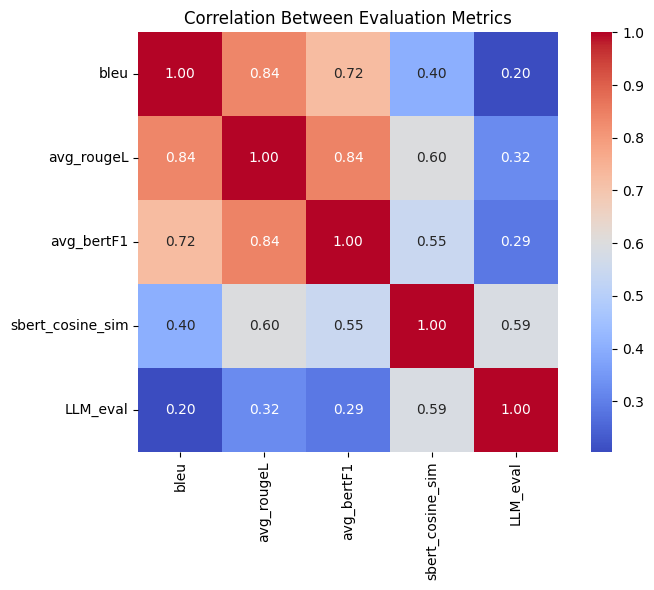

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the full evaluation results
df = pd.read_csv("rag_full_eval.csv")

# Compute correlation matrix between metrics
metrics = ["bleu", "avg_rougeL", "avg_bertF1", "sbert_cosine_sim", "LLM_eval"]
correlation_matrix = df[metrics].corr(method="pearson")

# Display correlation matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Between Evaluation Metrics")
plt.tight_layout()
plt.savefig("metric_correlation_matrix.png")
plt.show()


# Scratchpad

In [ ]:
# import os
# import re

# def clean_transcript(file_path):
#     # Derive the output filename by removing the trailing 'c' before .txt
#     base_name = os.path.basename(file_path)
#     if not base_name.endswith('c.txt'):
#         print(f"Skipped non-matching file: {file_path}")
#         return
    
#     output_name = base_name[:-5] + '.txt'  # remove 'c' and add '.txt'
#     output_path = os.path.join(os.path.dirname(file_path), output_name)

#     with open(file_path, 'r', encoding='utf-8') as infile:
#         lines = infile.readlines()

#     cleaned_lines = []
#     i = 0
#     while i < len(lines) - 2:
#         name1 = lines[i].strip()
#         name2 = lines[i + 1].strip()
#         time = lines[i + 2].strip()

#         if name1 == name2 and re.match(r'^\d{2}:\d{2}:\d{2}$', time):
#             i += 3  # skip these three lines
#         else:
#             cleaned_lines.append(lines[i])
#             i += 1

#     # Add any remaining lines at the end
#     while i < len(lines):
#         cleaned_lines.append(lines[i])
#         i += 1

#     with open(output_path, 'w', encoding='utf-8') as outfile:
#         outfile.writelines(cleaned_lines)

#     print(f"Cleaned file saved as: {output_path}")


# # Example usage
# clean_transcript("lecture-13c.txt")


In [ ]:
# from IPython.display import display, Latex

# # Display equation
# display(Math(r'E = mc^2'))

# # For text + equation
# display(Latex(r'The quadratic formula is: $x = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a}$'))
